Before cleaning :
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

FAfter cleaning : (333, 8)

 Summarize of the key statistics of the dataset. :
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      333.000000     333.000000         333.000000   333.000000   
mean        43.992793      17.164865         200.966967  4207.057057   
std          5.468668       1.969235          14.015765   805.215802   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.500000      15.600000         190.000000  3550.000000   
50%         44.500000      17.300000         197.000000  4050.000000   
75%         48.600000      18.700000         213.000000  4775.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   333.000000  
mean 

/tmp/ipykernel_5065/2112364240.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='species', palette='viridis')


<Figure size 1000x600 with 0 Axes>

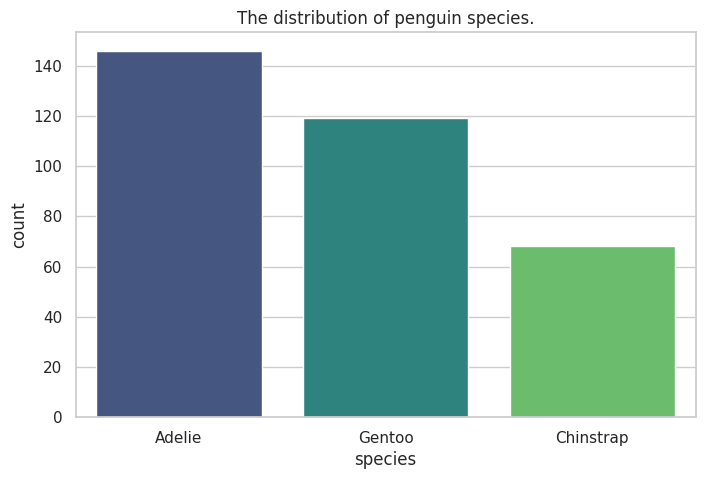

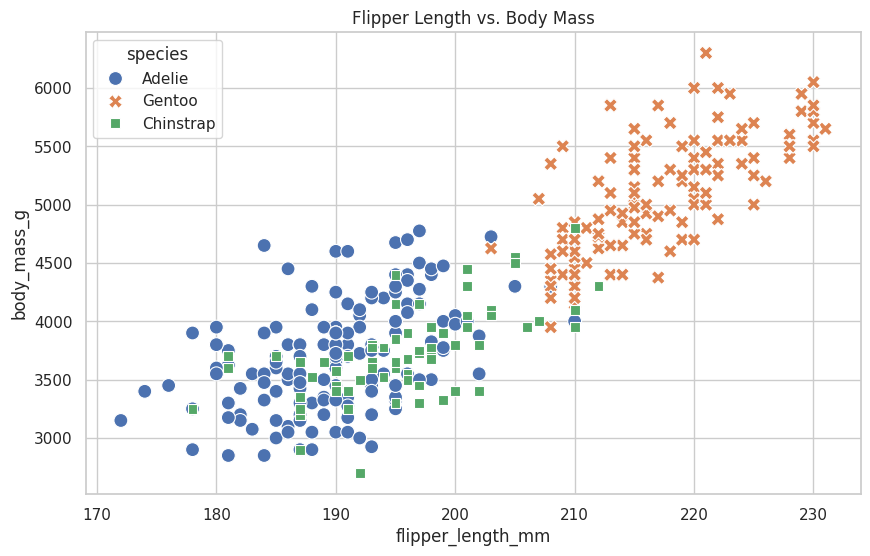

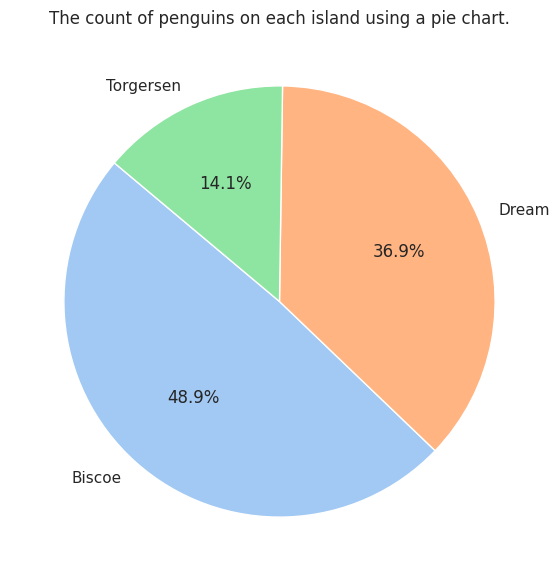

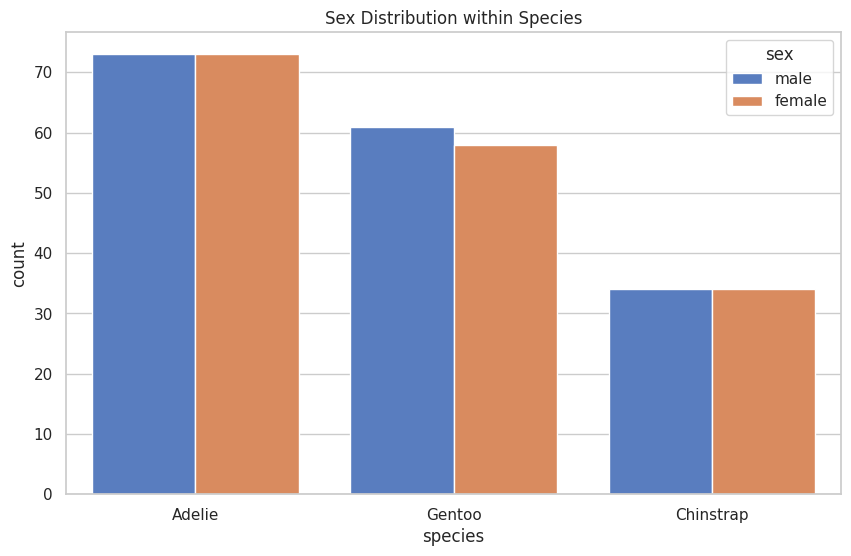

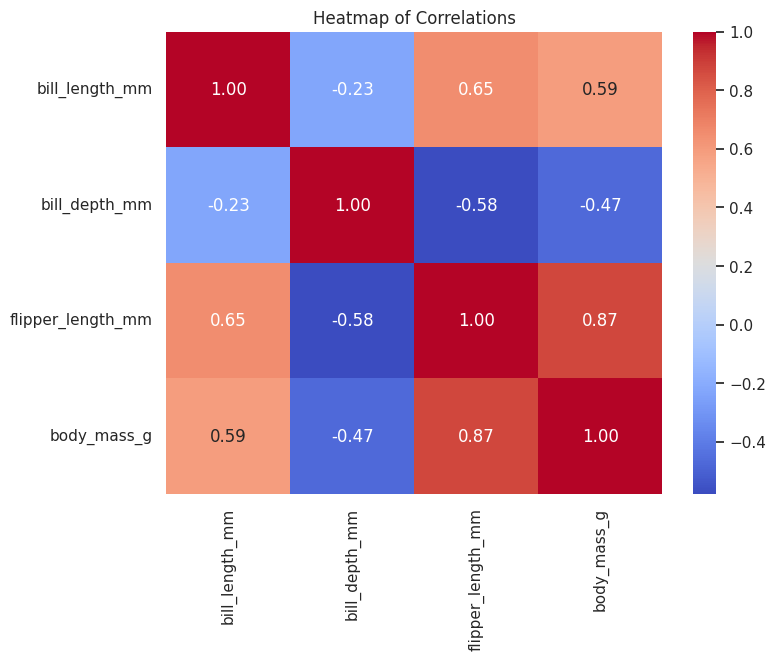

/tmp/ipykernel_5065/2112364240.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], data=df_clean, x='species', y='bill_length_mm', palette='Set2')
/tmp/ipykernel_5065/2112364240.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df_clean, x='species', y='bill_depth_mm', palette='Set2')
/tmp/ipykernel_5065/2112364240.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, 0], data=df_clean, x='species', y='flipper_length_mm', palette='Set2')
/tmp/ipykernel_5065/2112364240.py:71: FutureWarning: 

P

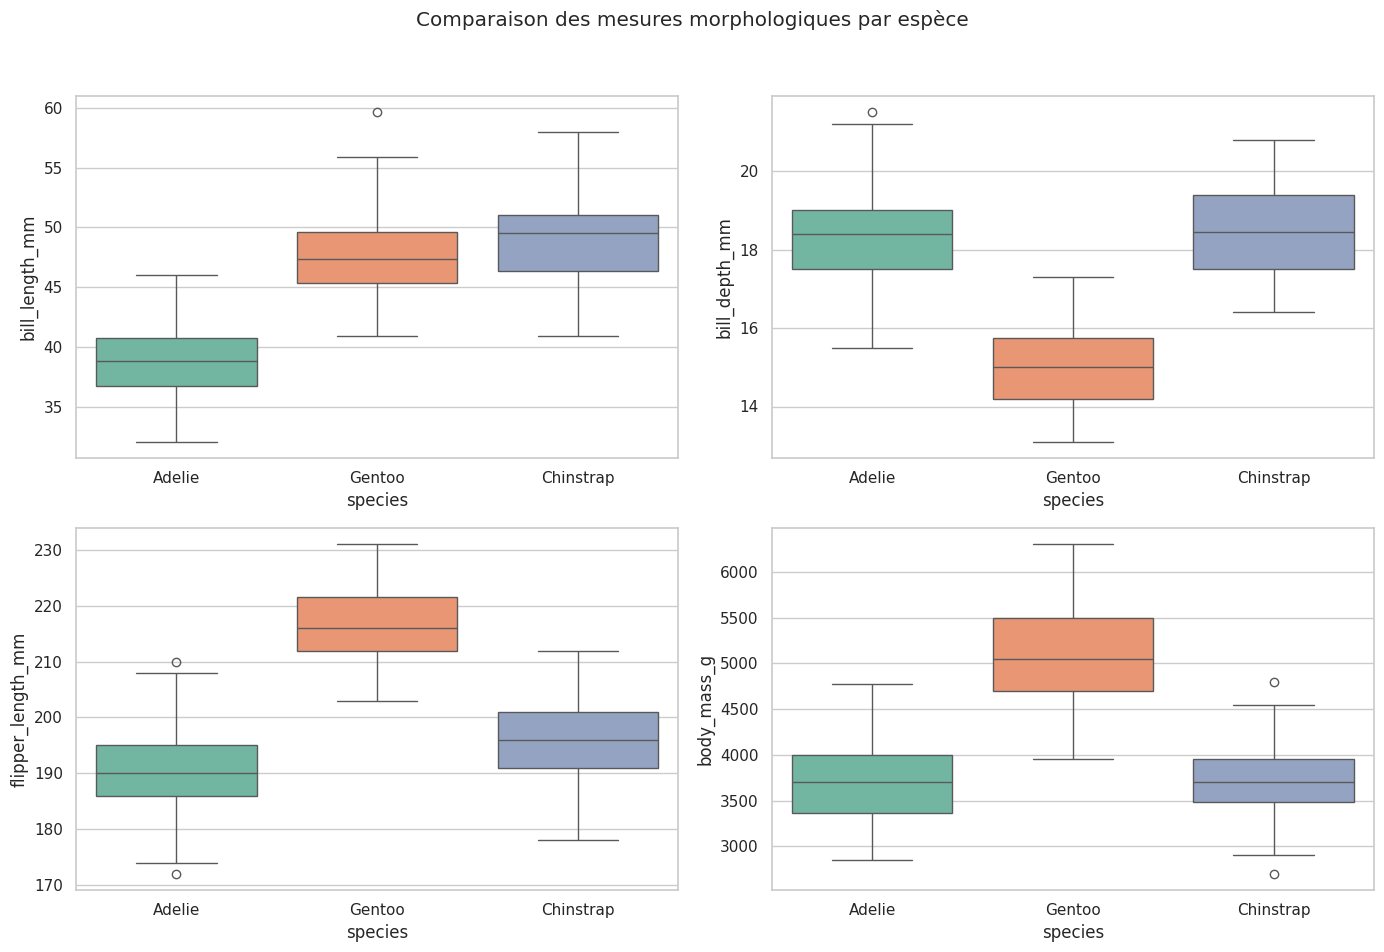

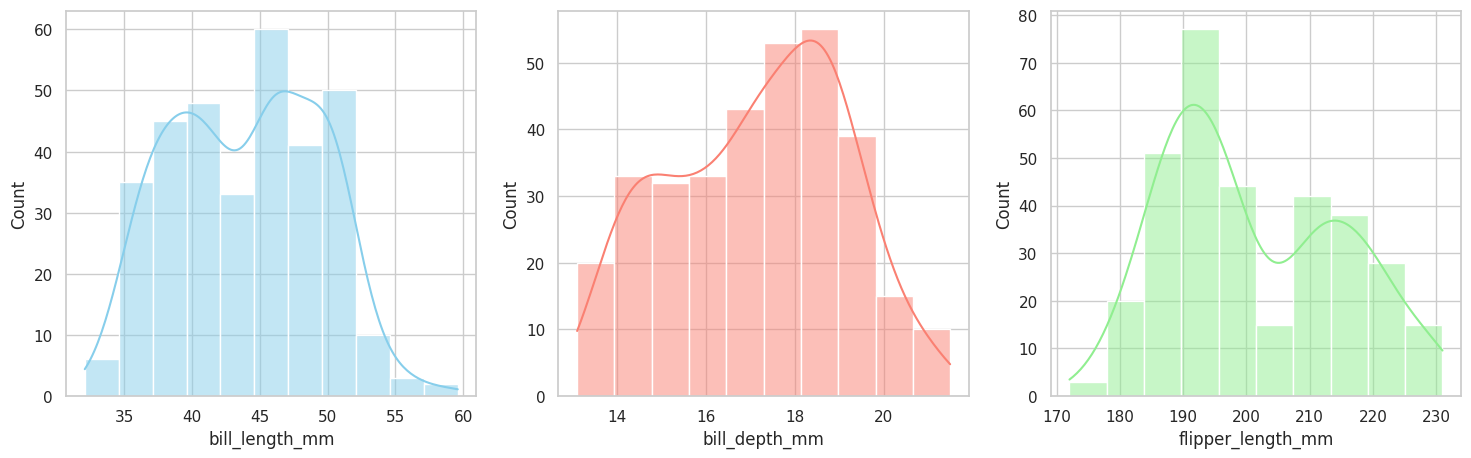

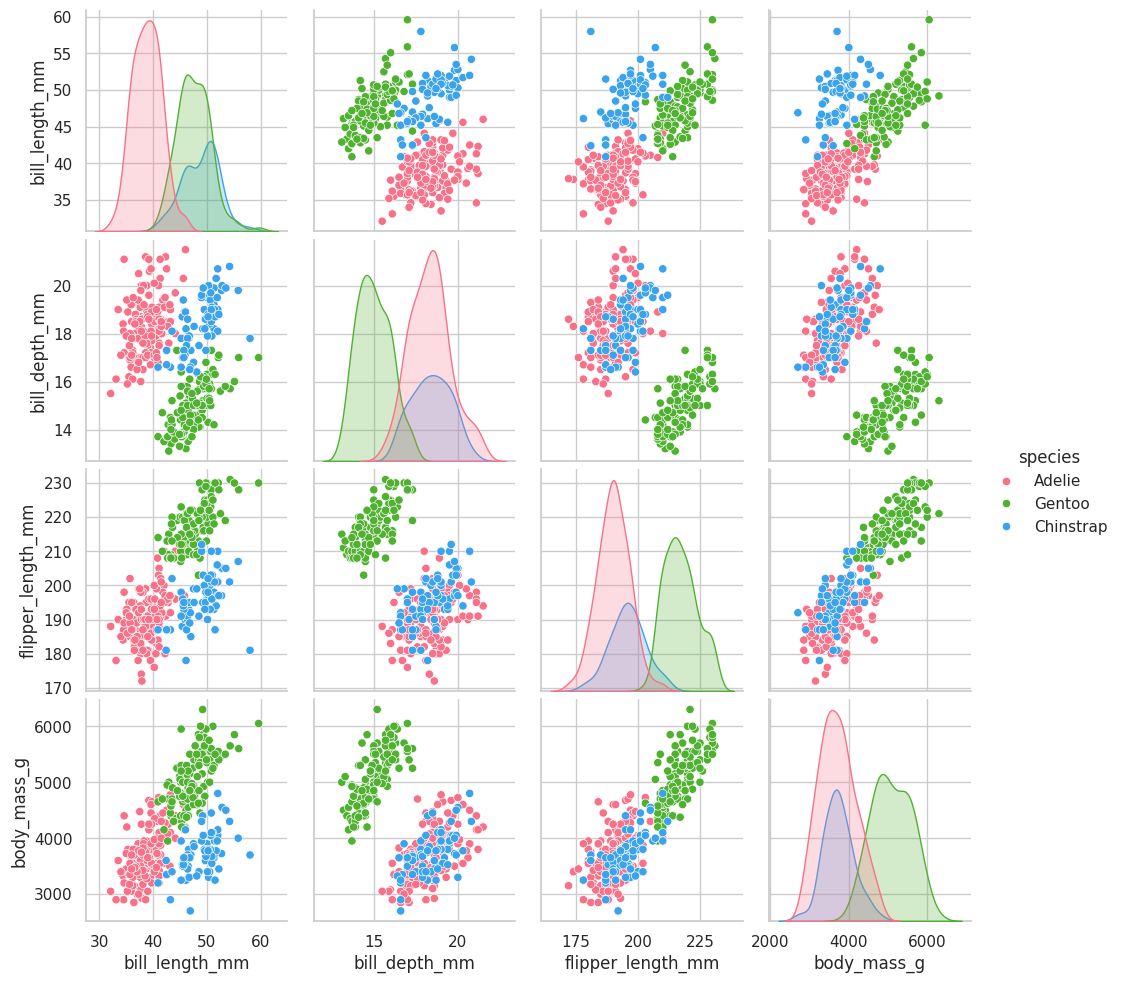

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# ==========================================
# 1. Data Loading and Cleaning:
# ==========================================


df = pd.read_csv('/content/Palmer Penguins Dataset.csv')

print("Before cleaning :\n", df.isnull().sum())


df_clean = df.dropna()

print(f"\nFAfter cleaning : {df_clean.shape}")

# ==========================================
# 2. (EDA)
# ==========================================

print("\n Summarize of the key statistics of the dataset. :")
print(df_clean.describe())

print("\nUnique values :")
for col in ['species', 'island', 'sex']:
    print(f"{col}: {df_clean[col].unique()}")

# ==========================================
# 3. Visualization Tasks:
# ==========================================

plt.figure(figsize=(10, 6))

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='species', palette='viridis')
plt.title('The distribution of penguin species.')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='flipper_length_mm', y='body_mass_g',
                hue='species', style='species', s=100)
plt.title('Flipper Length vs. Body Mass')
plt.show()

plt.figure(figsize=(7, 7))
island_counts = df_clean['island'].value_counts()
plt.pie(island_counts, labels=island_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('The count of penguins on each island using a pie chart.')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='species', hue='sex', palette='muted')
plt.title('Sex Distribution within Species')
plt.show()

plt.figure(figsize=(8, 6))
corr = df_clean.select_dtypes(include=['float64', 'int64']).drop(columns=['year']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Correlations')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(ax=axes[0, 0], data=df_clean, x='species', y='bill_length_mm', palette='Set2')
sns.boxplot(ax=axes[0, 1], data=df_clean, x='species', y='bill_depth_mm', palette='Set2')
sns.boxplot(ax=axes[1, 0], data=df_clean, x='species', y='flipper_length_mm', palette='Set2')
sns.boxplot(ax=axes[1, 1], data=df_clean, x='species', y='body_mass_g', palette='Set2')
plt.suptitle('Comparaison des mesures morphologiques par espèce')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean['bill_length_mm'], kde=True, ax=axes[0], color='skyblue')
sns.histplot(df_clean['bill_depth_mm'], kde=True, ax=axes[1], color='salmon')
sns.histplot(df_clean['flipper_length_mm'], kde=True, ax=axes[2], color='lightgreen')
plt.show()

# H. Pairplot
sns.pairplot(df_clean.drop(columns=['year']), hue='species', palette='husl')
plt.show()

**1. Data Loading and Cleaning**

The dataset was loaded and inspected for quality issues.
- Initial shape: 344 rows, 8 columns.
- Missing Values: We identified several missing entries in bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, and sex.
- Cleaning Action: Rows with missing values were removed to ensure accurate statistical analysis and visualization.
- Final shape: 333 rows.


**2. Exploratory Data Analysis (EDA)**

Summary statistics reveal the diversity among the three species: Adelie, Chinstrap, and Gentoo.
- Body Mass: Ranges from 2,700g to 6,300g, with an average of approximately 4,207g.
- Flipper Length: Ranges from 172mm to 231mm.
- Bill Length: Significant variation between species (minimum 32.1mm, maximum 59.6mm).


**3. Visual Analysis**

Species Distribution
The Adelie species is the most common in this dataset, while Chinstrap is the least frequent.

Flipper Length vs. Body Mass
There is a clear, strong positive correlation between flipper length and body mass. Interestingly, the species form distinct clusters: Gentoo penguins are significantly larger and have longer flippers compared to Adelie and Chinstrap penguins.

Island Distribution
Biscoe Island hosts the largest share of the penguin population (nearly 50%), followed by Dream Island. Torgersen Island has the smallest population in this dataset.

Sex Distribution within Species
The ratio of male to female penguins is roughly equal across all three species, indicating a balanced sample.

Heatmap of Correlations
The heatmap confirms that flipper length and body mass are the most highly correlated variables ($r \approx 0.87$). Bill length also shows a positive correlation with flipper length and body mass.

Boxplots for Measurements
These plots highlight the morphological differences:Gentoos are outliers in size, being much heavier with longer flippers.Adelies and Chinstraps have deeper bills compared to Gentoos.Chinstraps and Gentoos share similar long bill lengths, while Adelies have shorter bills.

Histograms of Measurements
The distributions of bill length and flipper length appear somewhat bimodal or multi-modal, reflecting the distinct physical characteristics of the different species grouped together.

Pairwise Relationships (Pairplot)
The pairplot allows us to see how all numerical variables interact simultaneously. It reinforces the observation that species can be largely identified just by looking at their physical measurements (e.g., Gentoo's high body mass and flipper length).

**4. Conclusion and Insights**

Based on the visual exploration, we can draw the following conclusions:
- Species Differentiation: Penguin species can be effectively distinguished by their physical measurements. Gentoo penguins are the "giants" of the group, while Adelie and Chinstrap are smaller but have deeper bills.
- Growth Patterns: There is a universal positive relationship between flipper size and body weight across all species.
- Habitat Specificity: Distribution is not uniform; for instance, Gentoo penguins in this dataset are primarily found on Biscoe island, which contributes to that island's high population count.- Biological Balance: The sample is well-balanced regarding sex, making it a robust dataset for comparing gender-based physical differences (where males generally tend to be slightly larger than females).